In [1]:
%pip install boto3 tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
!{sys.executable} -m pip install boto3

In [3]:
import boto3
print("Boto3 ready!")

Boto3 ready!


In [4]:
import boto3
import pandas as pd
import io
import os
from multiprocessing import Pool

#S3 client initiation
BUCKET_NAME = 'medical-data-sepsis-liwia-szemlet'
RAW_DATA_PREFIX = 'raw/' 
s3_client = boto3.client('s3')

print("Ready.")

Ready.


In [5]:
import boto3
import pandas as pd

BUCKET = 'medical-data-sepsis-liwia-sz'
s3 = boto3.resource('s3')
my_bucket = s3.Bucket(BUCKET)

count = sum(1 for _ in my_bucket.objects.filter(Prefix='raw/'))
print(f"Patients in the cloud: {count}")

for obj in my_bucket.objects.filter(Prefix='raw/training_setA/').limit(1):
    body = obj.get()['Body']
    df = pd.read_csv(body, sep='|')
    print("\nFirst patient data from S3:")
    print(df.head())

Patients in the cloud: 40336

First patient data from S3:
      HR  O2Sat  Temp    SBP    MAP  DBP  Resp  EtCO2  BaseExcess  HCO3  ...  \
0    NaN    NaN   NaN    NaN    NaN  NaN   NaN    NaN         NaN   NaN  ...   
1   97.0   95.0   NaN   98.0  75.33  NaN  19.0    NaN         NaN   NaN  ...   
2   89.0   99.0   NaN  122.0  86.00  NaN  22.0    NaN         NaN   NaN  ...   
3   90.0   95.0   NaN    NaN    NaN  NaN  30.0    NaN        24.0   NaN  ...   
4  103.0   88.5   NaN  122.0  91.33  NaN  24.5    NaN         NaN   NaN  ...   

   WBC  Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  \
0  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   
1  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   
2  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   
3  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   
4  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   

   ICULOS 

In [6]:
import boto3
import pandas as pd
import io
from tqdm import tqdm

BUCKET_NAME = 'medical-data-sepsis-liwia-sz'
s3_client = boto3.client('s3')

def process_sepsis_data(prefix, max_files=1000):
    """
    Downloads, combines, and performs basic imputation on patient data.
    """
    all_patient_data = []
    
    paginator = s3_client.get_paginator('list_objects_v2')
    pages = paginator.paginate(Bucket=BUCKET_NAME, Prefix=prefix)
    
    print(f"Starting ingestion for {prefix}...")
    
    file_count = 0
    for page in pages:
        for obj in page.get('Contents', []):
            if obj['Key'].endswith('.psv'):
                # Read from S3
                file_obj = s3_client.get_object(Bucket=BUCKET_NAME, Key=obj['Key'])
                df = pd.read_csv(io.BytesIO(file_obj['Body'].read()), sep='|')
                
                # Add Patient ID
                df['Patient_ID'] = obj['Key'].split('/')[-1].split('.')[0]

                df = df.ffill().bfill()
                
                all_patient_data.append(df)
                file_count += 1
                
                if file_count >= max_files:
                    break
        if file_count >= max_files:
            break
            
    final_df = pd.concat(all_patient_data, ignore_index=True)
    return final_df

# Processing
# Starting with 2000 patients for initial analysis
df_combined = process_sepsis_data('raw/training_setA/', max_files=2000)

print(f"Dataset ready. Shape: {df_combined.shape}")
print(f"Sepsis cases in this sample: {df_combined['SepsisLabel'].sum()}")

Starting ingestion for raw/training_setA/...
Dataset ready. Shape: (78083, 42)
Sepsis cases in this sample: 1760


In [7]:
# Now process Set B
df_b = process_sepsis_data('raw/training_setB/', max_files=2000)

# Dataframe concat
df_master = pd.concat([df_combined, df_b], ignore_index=True)

print(f"Total records in master dataset: {len(df_master)}")
print(f"Total unique patients: {df_master['Patient_ID'].nunique()}")

Starting ingestion for raw/training_setB/...
Total records in master dataset: 154808
Total unique patients: 4000


Highest positive correlations with SepsisLabel:
HR      0.053398
BUN     0.047201
Temp    0.045057
Resp    0.040666
WBC     0.040302
Name: SepsisLabel, dtype: float64

Highest negative correlations with SepsisLabel:
Hgb       -0.044500
Hct       -0.042285
Calcium   -0.038877
MAP       -0.025058
DBP       -0.020516
Name: SepsisLabel, dtype: float64


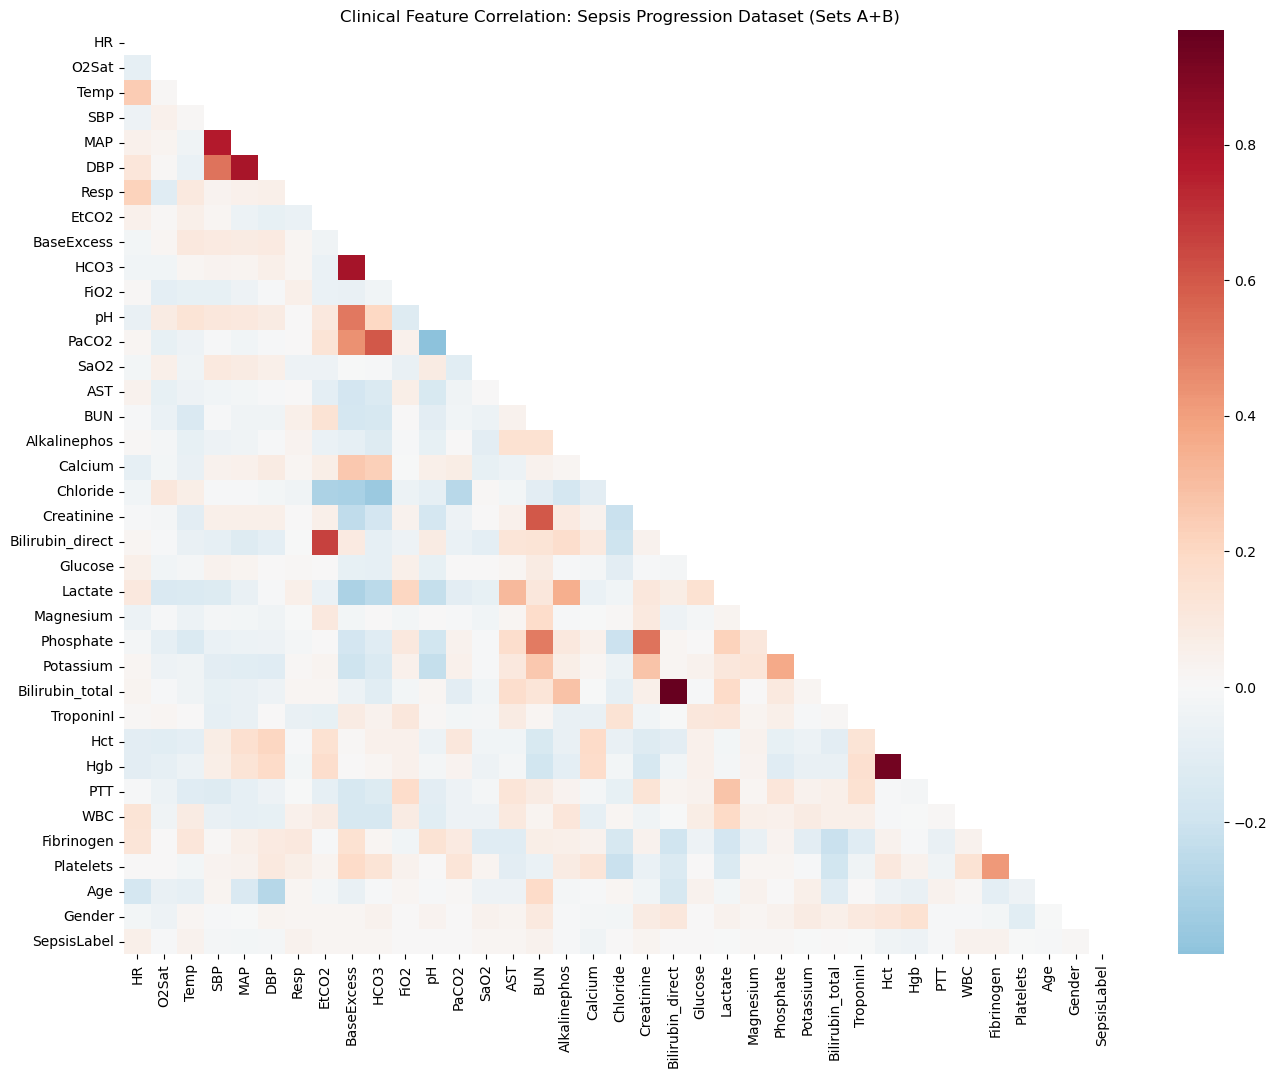

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# clinical variables and the target label selection
clinical_cols = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
    'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
    'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total',
    'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 
    'Age', 'Gender', 'SepsisLabel'
]

# Calculate the correlation matrix
corr_matrix = df_master[clinical_cols].corr()

# Plotting the Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0)
plt.title('Clinical Feature Correlation: Sepsis Progression Dataset (Sets A+B)')
plt.savefig('clinical_correlation_matrix.png', dpi=300, bbox_inches='tight')

# Print specific correlations with SepsisLabel
print("Highest positive correlations with SepsisLabel:")
print(corr_matrix['SepsisLabel'].sort_values(ascending=False).iloc[1:6])

print("\nHighest negative correlations with SepsisLabel:")
print(corr_matrix['SepsisLabel'].sort_values(ascending=True).iloc[:5])

In [9]:
# Create lag features to capture trends
def add_trends(df):
    df = df.sort_values(['Patient_ID', 'ICULOS'])
    
    # Calculate change in key vitals over last 3 hours
    for feat in ['HR', 'Temp', 'MAP', 'Resp']:
        df[f'{feat}_diff'] = df.groupby('Patient_ID')[feat].diff(periods=3)
    
    return df

df_master = add_trends(df_master)

# Check Class Imbalance
imbalance = df_master['SepsisLabel'].value_counts(normalize=True) * 100
print(f"Sepsis Label Distribution:\n{imbalance}")

Sepsis Label Distribution:
SepsisLabel
0    98.14932
1     1.85068
Name: proportion, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split

# Get unique patient IDs
patients = df_master['Patient_ID'].unique()

# Split: 80% train, 20% test
train_ids, test_ids = train_test_split(patients, test_size=0.2, random_state=42)

# Create train and test dataframes
train_df = df_master[df_master['Patient_ID'].isin(train_ids)]
test_df = df_master[df_master['Patient_ID'].isin(test_ids)]

print(f"Training on: {len(train_ids)} patients")
print(f"Testing on: {len(test_ids)} patients")

Training on: 3200 patients
Testing on: 800 patients


In [11]:
sepsis_cases = train_df[train_df['SepsisLabel'] == 1]
healthy_cases = train_df[train_df['SepsisLabel'] == 0]

# Downsampling healthy cases to a 3:1 ratio for better learning
healthy_downsampled = healthy_cases.sample(n=len(sepsis_cases) * 3, random_state=42)

train_balanced = pd.concat([sepsis_cases, healthy_downsampled]).sample(frac=1)

print(f"Balanced training set size: {len(train_balanced)}")
print(f"New Sepsis distribution:\n{train_balanced['SepsisLabel'].value_counts(normalize=True)}")

Balanced training set size: 9208
New Sepsis distribution:
SepsisLabel
0    0.75
1    0.25
Name: proportion, dtype: float64


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

features = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp', 'Age', 'Gender', 'ICULOS']
X_train = train_balanced[features].fillna(0)
y_train = train_balanced['SepsisLabel']

X_test = test_df[features].fillna(0)
y_test = test_df['SepsisLabel']

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Results
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[28828  1730]
 [  354   209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     30558
           1       0.11      0.37      0.17       563

    accuracy                           0.93     31121
   macro avg       0.55      0.66      0.57     31121
weighted avg       0.97      0.93      0.95     31121



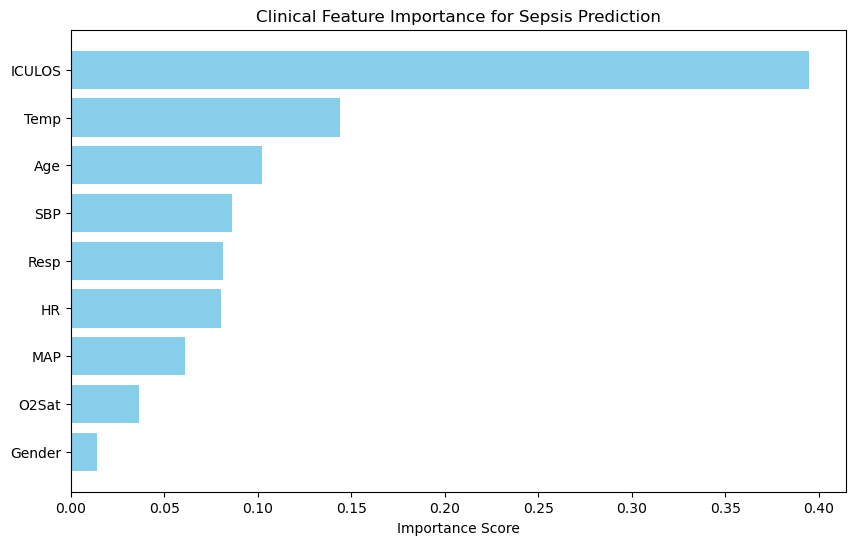

<Figure size 640x480 with 0 Axes>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Clinical Feature Importance for Sepsis Prediction')
plt.gca().invert_yaxis()
plt.show()
plt.savefig('sepsis_feature_importance.png', dpi=300, bbox_inches='tight')

In [14]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


Final Clinical Performance Metrics:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     30558
           1       0.07      0.46      0.13       563

    accuracy                           0.89     31121
   macro avg       0.53      0.68      0.53     31121
weighted avg       0.97      0.89      0.92     31121



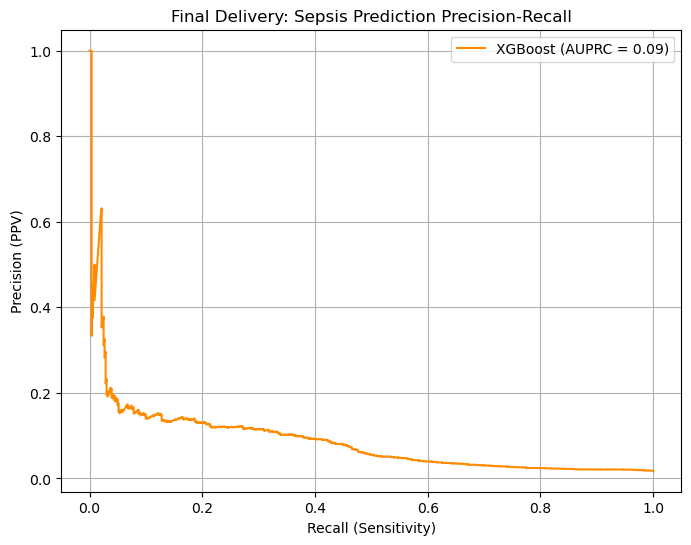

<Figure size 640x480 with 0 Axes>

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculating imbalance ratio to boost recall
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Initializing XGBoost
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # Critical for 1.8% prevalence
    eval_metric='aucpr'
)

# Training on balanced data
xgb_model.fit(X_train, y_train)

# Generating predictions
y_probs = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

# Reporting results
print("Final Clinical Performance Metrics:")
print(classification_report(y_test, y_pred))

# Plotting precision-recall for delivery
precision, recall, _ = precision_recall_curve(y_test, y_probs)
auc_score = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', label=f'XGBoost (AUPRC = {auc_score:.2f})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (PPV)')
plt.title('Final Delivery: Sepsis Prediction Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')

In [16]:
# Feature engineering - an attempt to capture even more sepsis cases
df_master = df_master.sort_values(['Patient_ID', 'ICULOS'])

# Shock Index is a name for a critical medical marker (HR / Systolic BP)
df_master['Shock_Index'] = df_master['HR'] / df_master['SBP']

# 3-Hour Delta
df_master['HR_delta'] = df_master.groupby('Patient_ID')['HR'].diff(periods=3)
df_master['Temp_delta'] = df_master.groupby('Patient_ID')['Temp'].diff(periods=3)

# Smoothing sensor noise
df_master['MAP_6hr_avg'] = df_master.groupby('Patient_ID')['MAP'].transform(lambda x: x.rolling(6, min_periods=1).mean())

# Updating Feature List
pro_features = ['HR', 'Temp', 'MAP', 'Shock_Index', 'HR_delta', 'Temp_delta', 'MAP_6hr_avg', 'Age', 'ICULOS']

# New Train/Test Split with the updated feature list
train_df = df_master[df_master['Patient_ID'].isin(train_ids)]
test_df = df_master[df_master['Patient_ID'].isin(test_ids)]

X_train_pro = train_df[pro_features].fillna(0)
y_train_pro = train_df['SepsisLabel']
X_test_pro = test_df[pro_features].fillna(0)
y_test_pro = test_df['SepsisLabel']

# 4. Final XGBoost Model
from xgboost import XGBClassifier

# High weight for sepsis class 1 to maximize recall
ratio_pro = len(y_train_pro[y_train_pro==0]) / len(y_train_pro[y_train_pro==1])

xgb_final = XGBClassifier(
    n_estimators=250,
    max_depth=7,
    learning_rate=0.05,
    scale_pos_weight=ratio_pro * 1.5,
    eval_metric='aucpr'
)

xgb_final.fit(X_train_pro, y_train_pro)

# Results
y_pred_final = xgb_final.predict(X_test_pro)
print(classification_report(y_test_pro, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     30558
           1       0.06      0.37      0.11       563

    accuracy                           0.89     31121
   macro avg       0.53      0.63      0.53     31121
weighted avg       0.97      0.89      0.93     31121



In [17]:
# Prediction of probability for specific groups of patients

# Checking the risk for the first 10 patients in the test set
# Looking at the probability instead of 0 / 1
test_df = test_df.copy()
test_df.loc[:, 'Sepsis_Risk_Probability'] = xgb_final.predict_proba(X_test_pro)[:, 1]

# Display patients with the highest risk scores
risk_dashboard = test_df[['Patient_ID', 'ICULOS', 'HR', 'Temp', 'Sepsis_Risk_Probability', 'SepsisLabel']]
print("Top 10 High-Risk Patients identified by the Model:")
print(risk_dashboard.sort_values(by='Sepsis_Risk_Probability', ascending=False).head(10))
risk_dashboard.sort_values(by='Sepsis_Risk_Probability', ascending=False).head(20).to_csv('top_risk_patients.csv', index=False)

Top 10 High-Risk Patients identified by the Model:
      Patient_ID  ICULOS     HR   Temp  Sepsis_Risk_Probability  SepsisLabel
31978    p000819      14   80.0  35.56                 0.981293            0
75127    p001925      23   85.0  37.11                 0.980795            0
31977    p000819      13   81.0  35.56                 0.979398            0
31976    p000819      12   81.0  35.56                 0.977812            0
31995    p000819      31   82.0  36.28                 0.977310            0
31989    p000819      25   80.0  36.06                 0.976257            0
31979    p000819      15   79.0  35.50                 0.974451            0
75125    p001925      21   80.0  37.06                 0.973898            0
31996    p000819      32   95.0  36.11                 0.973580            0
508      p000009     205  117.0  37.72                 0.972902            0


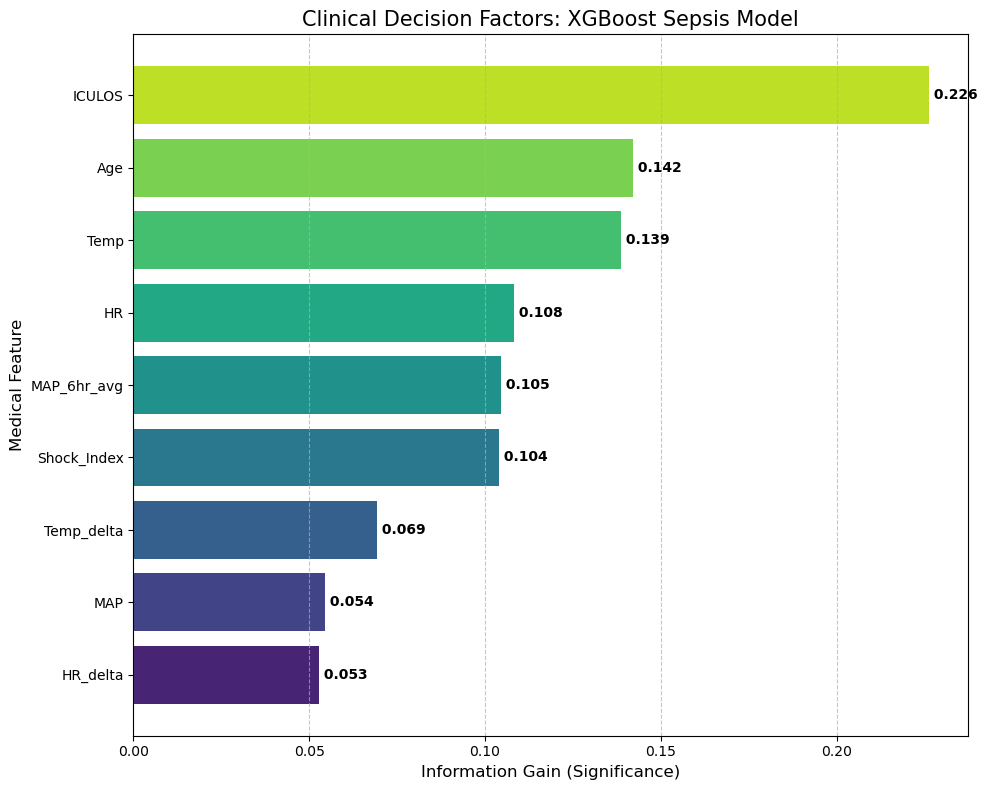

<Figure size 640x480 with 0 Axes>

In [18]:
# Clinical feature importance check
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = xgb_final.feature_importances_
feature_names = pro_features

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(fi_df))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors)

plt.title('Clinical Decision Factors: XGBoost Sepsis Model', fontsize=15)
plt.xlabel('Information Gain (Significance)', fontsize=12)
plt.ylabel('Medical Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(fi_df['Importance']):
    plt.text(value, index, f' {value:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig('clinical_decision_factors.png', dpi=300, bbox_inches='tight')

In [19]:
# Conclusion aka final thought - How many patients actually have label=1 = positive sepsis diagnosis among top 100 most dangerous cases?

top_100 = risk_dashboard.sort_values(by='Sepsis_Risk_Probability', ascending=False).head(100)
sepsis_found = top_100[top_100['SepsisLabel'] == 1].shape[0]

print(f"Confirmed sepsis cases among top100 most dangerous ones: {sepsis_found}")

Confirmed sepsis cases among top100 most dangerous ones: 12


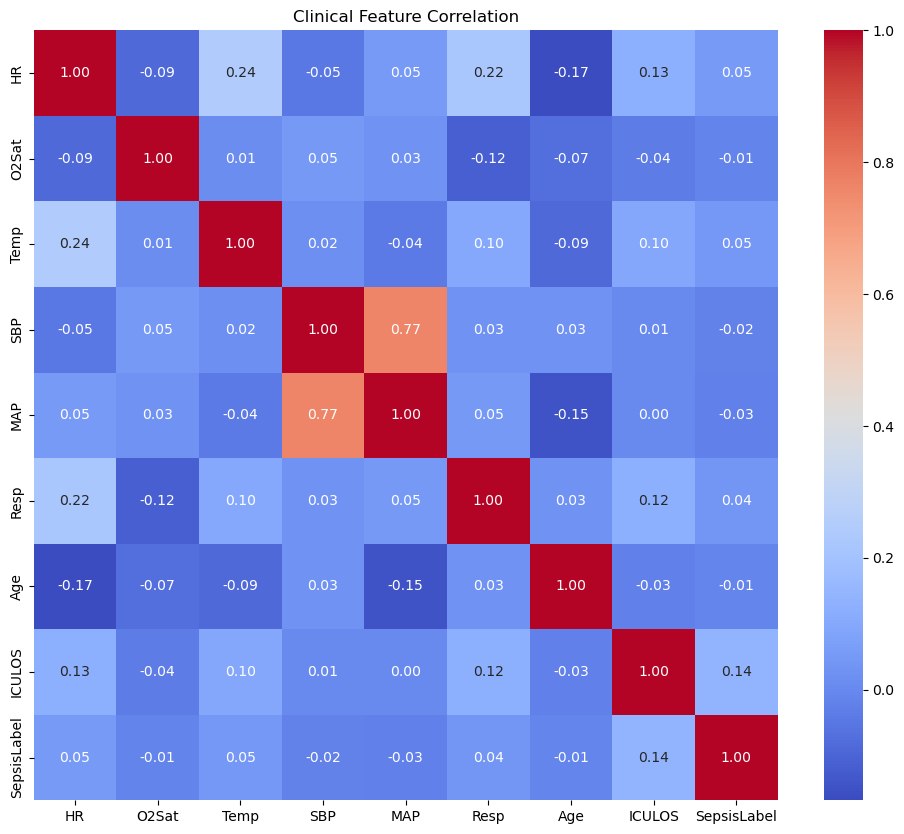

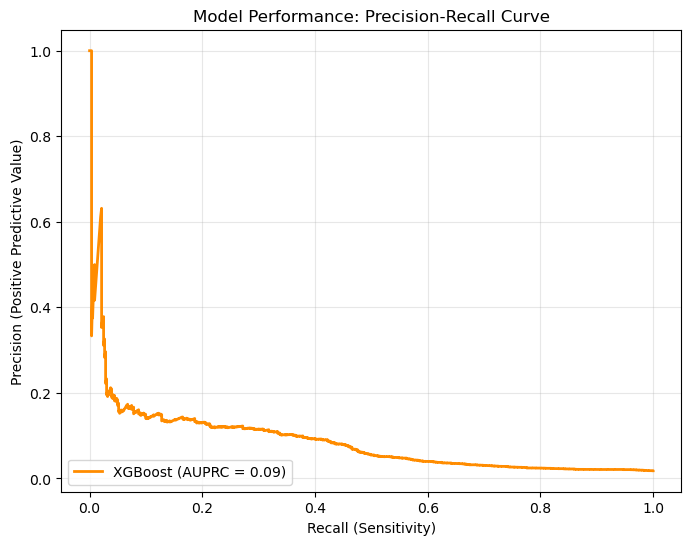

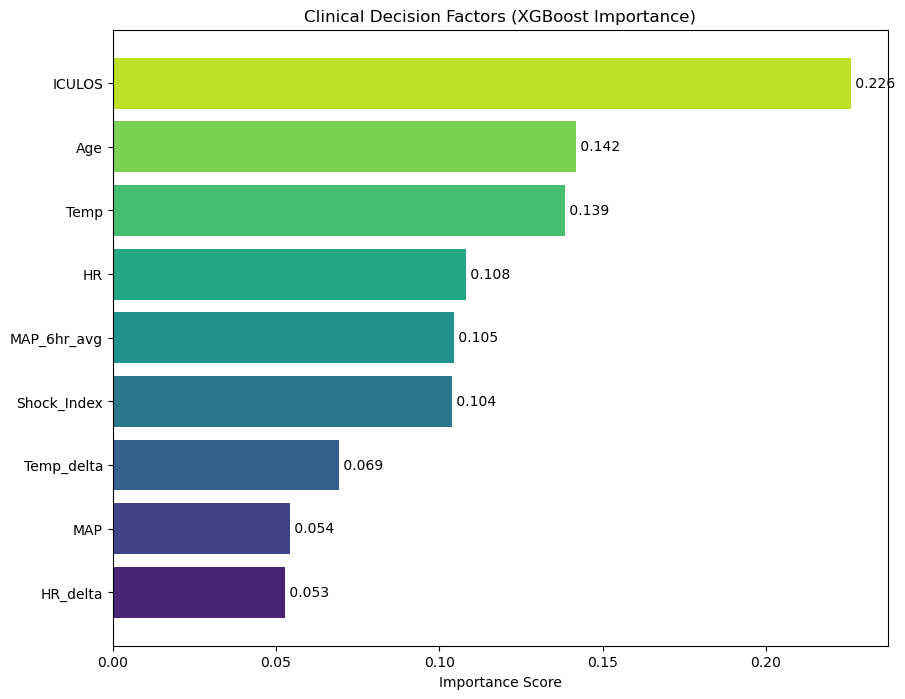

Visualizations saved in 'portfolio_sepsis_project_v1'


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

output_dir = 'portfolio_sepsis_project_v1'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.figure(figsize=(12, 10))

corr_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp', 'Age', 'ICULOS', 'SepsisLabel']
sns.heatmap(df_master[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Clinical Feature Correlation')
plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'XGBoost (AUPRC = {auc_score:.2f})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Model Performance: Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.savefig(f'{output_dir}/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 8))

fi_df = pd.DataFrame({'Feature': pro_features, 'Importance': xgb_final.feature_importances_})
fi_df = fi_df.sort_values(by='Importance', ascending=True)

colors = sns.color_palette("viridis", len(fi_df))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
plt.title('Clinical Decision Factors (XGBoost Importance)')
plt.xlabel('Importance Score')

for index, value in enumerate(fi_df['Importance']):
    plt.text(value, index, f' {value:.3f}', va='center')

plt.savefig(f'{output_dir}/clinical_decision_factors.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualizations saved in '{output_dir}'")